In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fanalysis.ca import CA
from matplotlib.ticker import PercentFormatter

data = pd.read_csv('data.csv')

### Diagrammes en barre décrivant la proportion de chaque item en fonction de l'étape du raisonnement clinique.  

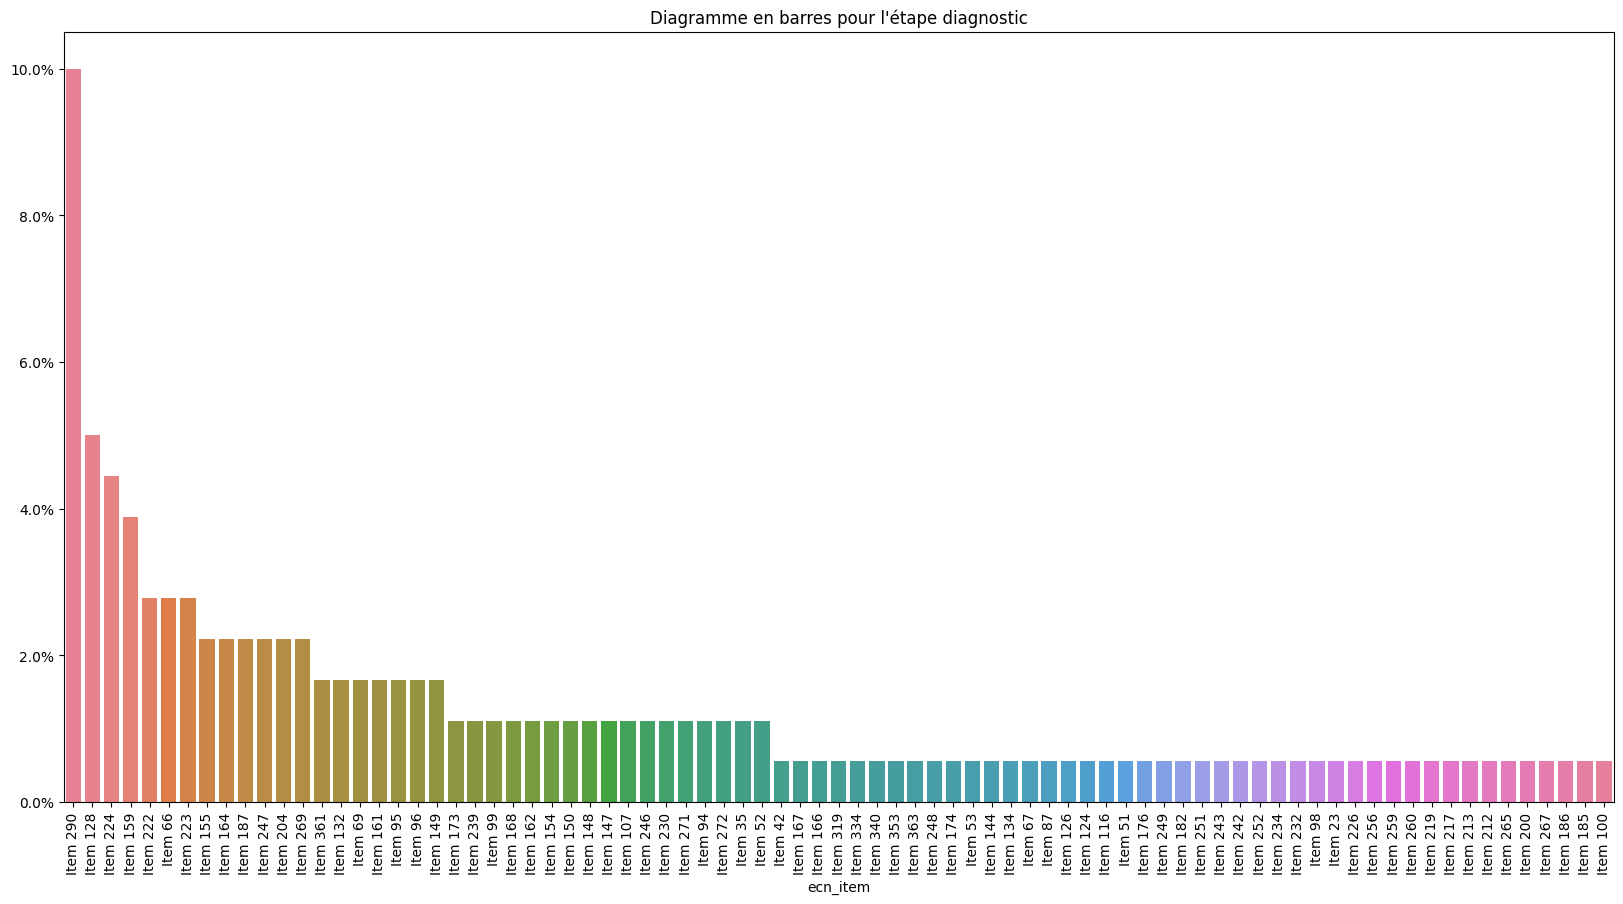

Valeurs absolues : 



ecn_item,Item 290,Item 128,Item 224,Item 159,Item 222,Item 66,Item 223,Item 155,Item 164,Item 187,...,Item 219,Item 217,Item 213,Item 212,Item 265,Item 200,Item 267,Item 186,Item 185,Item 100
diagnostic,18,9,8,7,5,5,5,4,4,4,...,1,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 290,Item 128,Item 224,Item 159,Item 222,Item 66,Item 223,Item 155,Item 164,Item 187,...,Item 219,Item 217,Item 213,Item 212,Item 265,Item 200,Item 267,Item 186,Item 185,Item 100
diagnostic,0.1,0.05,0.044444,0.038889,0.027778,0.027778,0.027778,0.022222,0.022222,0.022222,...,0.005556,0.005556,0.005556,0.005556,0.005556,0.005556,0.005556,0.005556,0.005556,0.005556


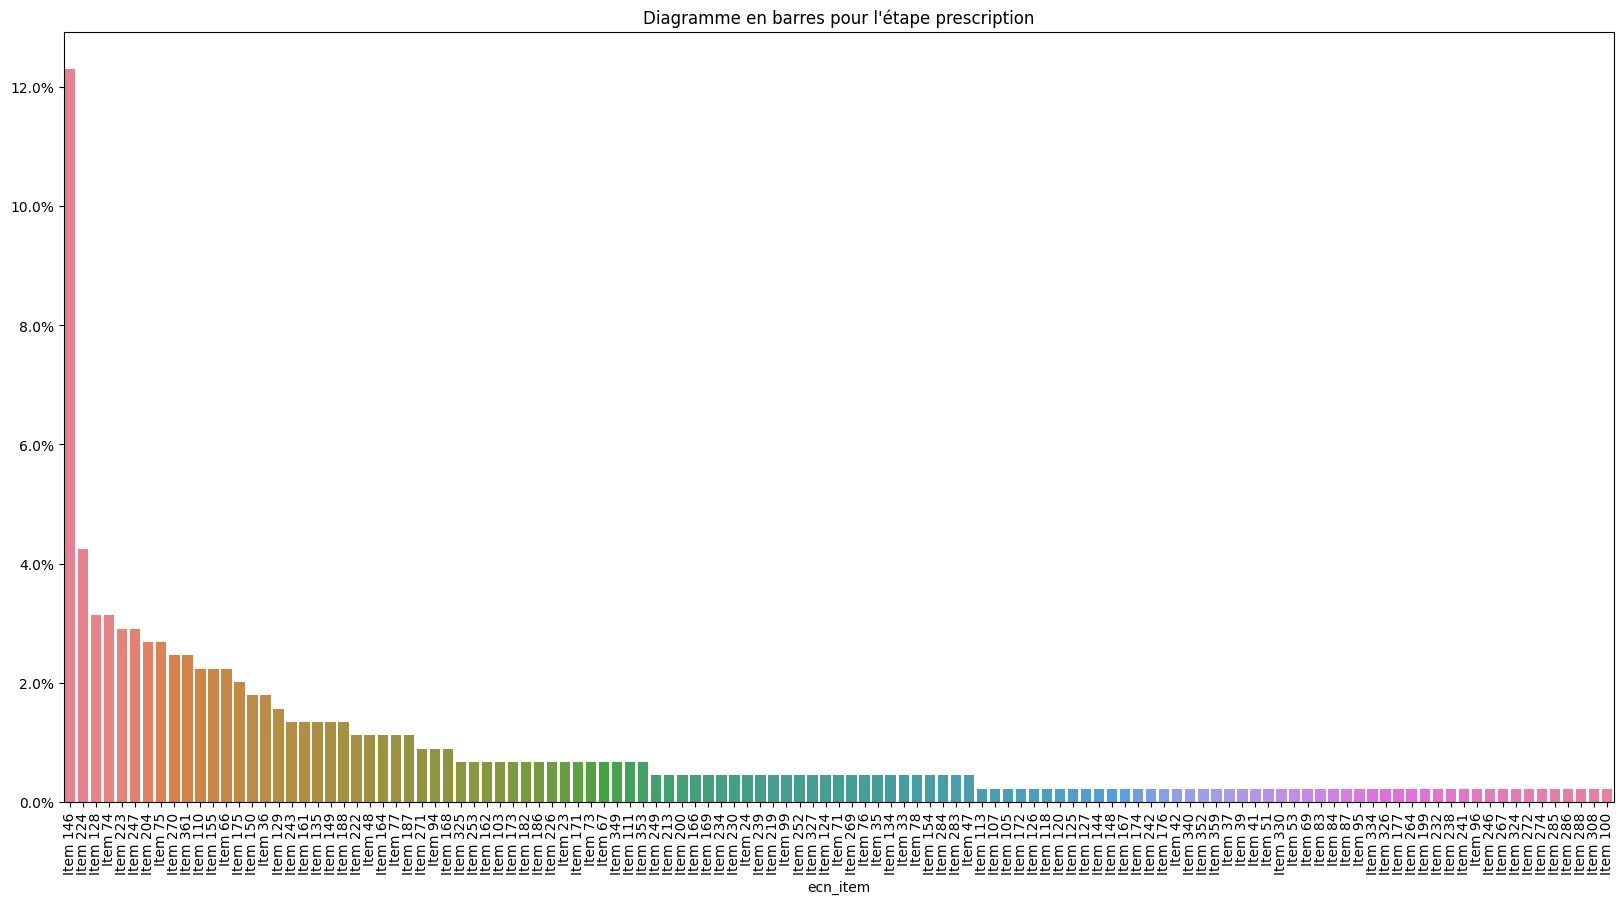

Valeurs absolues : 



ecn_item,Item 146,Item 224,Item 128,Item 74,Item 223,Item 247,Item 204,Item 75,Item 270,Item 361,...,Item 246,Item 267,Item 324,Item 272,Item 274,Item 285,Item 286,Item 288,Item 308,Item 100
prescription,55,19,14,14,13,13,12,12,11,11,...,1,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 146,Item 224,Item 128,Item 74,Item 223,Item 247,Item 204,Item 75,Item 270,Item 361,...,Item 246,Item 267,Item 324,Item 272,Item 274,Item 285,Item 286,Item 288,Item 308,Item 100
prescription,0.123043,0.042506,0.03132,0.03132,0.029083,0.029083,0.026846,0.026846,0.024609,0.024609,...,0.002237,0.002237,0.002237,0.002237,0.002237,0.002237,0.002237,0.002237,0.002237,0.002237


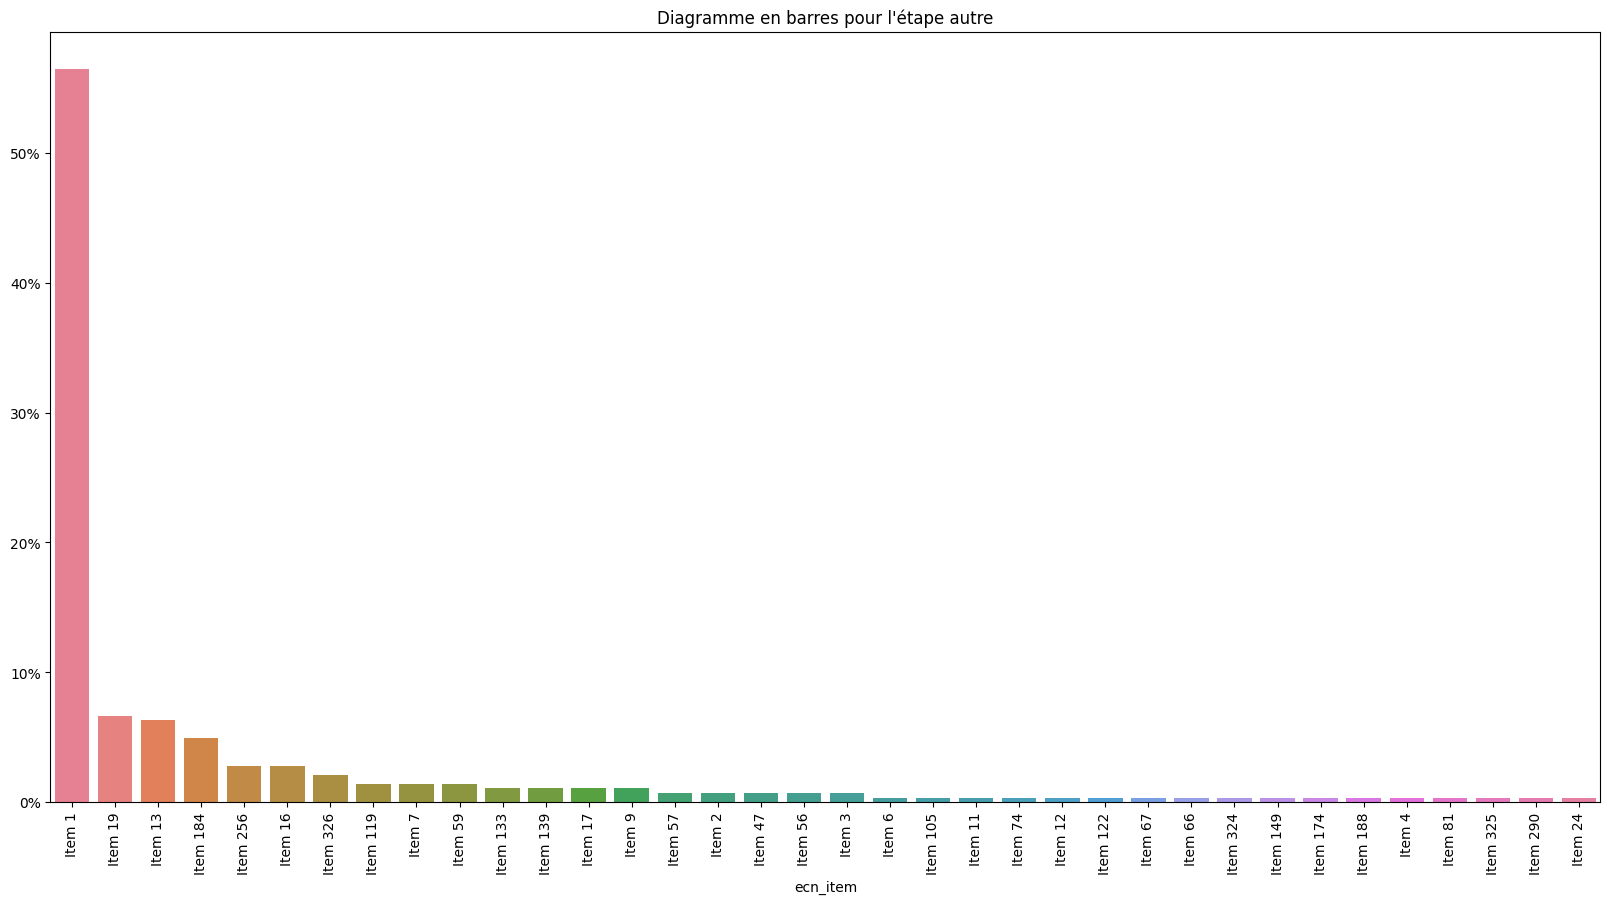

Valeurs absolues : 



ecn_item,Item 1,Item 19,Item 13,Item 184,Item 256,Item 16,Item 326,Item 119,Item 7,Item 59,...,Item 66,Item 324,Item 149,Item 174,Item 188,Item 4,Item 81,Item 325,Item 290,Item 24
autre,161,19,18,14,8,8,6,4,4,4,...,1,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 1,Item 19,Item 13,Item 184,Item 256,Item 16,Item 326,Item 119,Item 7,Item 59,...,Item 66,Item 324,Item 149,Item 174,Item 188,Item 4,Item 81,Item 325,Item 290,Item 24
autre,0.564912,0.066667,0.063158,0.049123,0.02807,0.02807,0.021053,0.014035,0.014035,0.014035,...,0.003509,0.003509,0.003509,0.003509,0.003509,0.003509,0.003509,0.003509,0.003509,0.003509


In [2]:
data_gpByItem = data.groupby(['ecn_item']).agg(
    diagnostic = ('step_diag', 'sum'),
    prescription = ('step_PEC_TTT', 'sum'), 
    autre = ('step_autre', 'sum')
)

data_gpByItem = data_gpByItem.transpose()

for i in range(0,data_gpByItem.shape[0]):
    row = data_gpByItem.iloc[[i]]
    row = row.dropna(axis=1, how='all')
    row = row.loc[:, row.iloc[0] != 0]
    row = row[row.columns[row.iloc[0].argsort()[::-1]]]

    rowProp = row.copy()
    rowProp[row.columns] = row[row.columns].div(row[row.columns].sum(axis=1), axis=0)

    plt.figure(figsize=(20, 10))
    sns.barplot(rowProp)
    plt.xticks(rotation=90)
    plt.title(f"Diagramme en barres pour l'étape {data_gpByItem.index[i]}")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.show()  
    print("Valeurs absolues : \n")
    display(row)
    print("Proportions : \n")
    display(rowProp)
